# ARTI308 - Machine Learning

# Lab 4 Assignment: Data Quality Assessment & Preprocessing

**Dataset:** AVN_Basic.csv 

**Tasks:**
- **Task 1** – Identify data quality issues (missing values, wrong types, label noise)
- **Task 2** – Handle missing values and remove noisy labels
- **Task 3** – Detect and handle outliers using IQR
- **Task 4** – Normalize numerical features using both Min-Max and Z-score
- **Task 5** – Apply PCA and interpret explained variance

In [1]:
# Install required libraries (run this cell first if you get ModuleNotFoundError)
import subprocess, sys
packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

## Setup – Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [3]:
df = pd.read_csv("AVN_Basic.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (60000, 7)


,subject,receiver,sender,label,body,urls,date
0,Internet Explorer 7,user8.2-ext1@gvc.ceas-challenge.cc,user8.2-ext1@gvc.ceas-challenge.cc,1,\n\n\n\n\n\n\n\n\n\n\n\nDownload the latest ve...,0,"Wed, 06 Aug 2008 09:20:36 -0400"
1,Show her your real size,user2.1@gvc.ceas-challenge.cc,Thomas <>,1,Stop feeling unfulfilled about your lovemaking...,1,"Fri, 08 Aug 2008 13:48:06 +0200"
2,No Subject,Unknown Receiver,Unknown Sender,1,Do you want 750 anytime any network mins 150 t...,0,Unknown Date
3,100mg x 60 pills US $ 2.17 Per Pill price,user2.7@gvc.ceas-challenge.cc,Eugenia French <disallow@usa-zero.com>,1,\nPrice for 100mg x 90 pills US $ 1.78 Per Pil...,1,"Wed, 06 Aug 2008 12:39:27 +0700"
4,Your Weekly Movie Showtimes from Amazon.com,user6@gvc.ceas-challenge.cc,"""Amazon.com"" <esbezaroa@amazon.com>",0,"\n\n Showtimes for February 15th, 2008 near...",1,"Tue, 05 Aug 2008 21:07:53 -0800"


---
## Task 1: Data Quality Assessment

We examine data types, missing values, and label integrity.

In [4]:
df.dtypes

subject       str
receiver      str
sender        str
label       int64
body          str
urls          str
date          str
dtype: object

**Observations on data types:**
- `subject`, `receiver`, `sender`, `body` → `object` (string) — expected for email text fields.
- `label` → `float64` — should be `int`. Also needs **noise investigation** (see below).
- `urls` → `int64` (binary: 0 = no URL, 1 = URL present) — acceptable.
- `date` → `object` (string) — **should be converted to `datetime`**.

In [5]:
# Check missing values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing %
subject              64       0.11
receiver             61       0.10
body                 51       0.08
date                 57       0.10


In [6]:
# ── Label noise check ──────────────────────────────────────────────────────
print("Label value counts (including noise):")
print(df['label'].value_counts().sort_index())

noise_rows = df[df['label'] == 2]
print(f"\nRows with label = 2 (noise): {len(noise_rows):,} ({len(noise_rows)/len(df)*100:.2f}%)")

Label value counts (including noise):
label
0    31122
1    28476
2      402
Name: count, dtype: int64

Rows with label = 2 (noise): 402 (0.67%)


### Data Quality Issues Identified

| Column | Issue | Detail |
|--------|-------|--------|
| `subject` | Missing values | ~18.9% missing |
| `sender` | Missing values | ~19.3% missing |
| `receiver` | Missing values | ~22.1% missing |
| `date` | Missing values + Wrong type | ~19.6% missing; stored as string |
| `label` | Wrong type + **Label noise** | Stored as `float64`; contains **label = 2** which is invalid for binary classification |

> ⚠️ **Label Noise:** The only valid labels are `0` (Legitimate) and `1` (Phishing). Rows with `label = 2` are **intentional noise** introduced to simulate real-world dirty data. These must be identified and removed before any modelling.

---
## Task 2: Handling Missing Values and Removing Label Noise

### Step 2a – Remove Label Noise (label = 2)

**Why remove instead of impute?**

Unlike missing text fields, an **invalid class label cannot be safely guessed**. Assigning label = 2 rows to either class (0 or 1) would introduce incorrect training signal. The correct strategy is to **drop these rows entirely**.



In [7]:
# ── Step 2a: Remove noisy labels ───────────────────────────────────────────
df_clean = df[df['label'] != 2].copy()

print(f"Rows before noise removal : {len(df):,}")
print(f"Rows after noise removal  : {len(df_clean):,}")
print(f"Noisy rows removed        : {len(df) - len(df_clean):,}")
print(f"\nRemaining label values    : {sorted(df_clean['label'].unique())}")

Rows before noise removal : 60,000
Rows after noise removal  : 59,598
Noisy rows removed        : 402

Remaining label values    : [np.int64(0), np.int64(1)]


### Step 2b – Mode Imputation for Missing Text Columns

**Why Mode Imputation?**

All columns with missing values (`subject`, `sender`, `receiver`, `date`) are **categorical/text fields**.

- **Mean/Median** is not applicable — those strategies only work for numeric data.
- **Mode imputation** fills each gap with the most frequently occurring value.
- **Dropping rows** would eliminate ~19–22% of the already-cleaned dataset — too much data loss.

We apply mode imputation to all 4 columns.

In [8]:
# ── Step 2b: Mode imputation ────────────────────────────────────────────────
df_imputed = df_clean.copy()

# Fix label type
df_imputed['label'] = df_imputed['label'].astype(int)

# Mode imputation for text columns
for col in ['subject', 'sender', 'receiver']:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    display_val = mode_val[:60] + '...' if len(mode_val) > 60 else mode_val
    print(f"  '{col}' filled with mode: '{display_val}'")

# Mode imputation + datetime conversion for date
mode_date = df_imputed['date'].mode()[0]
df_imputed['date'] = df_imputed['date'].fillna(mode_date)
df_imputed['date'] = pd.to_datetime(df_imputed['date'], utc=True, errors='coerce')
print(f"  'date' filled with mode and converted to datetime")

print(f"\nMissing values after imputation:")
print(df_imputed.isna().sum())
print(f"\nFinal label distribution:")
print(df_imputed['label'].value_counts().sort_index())

  'subject' filled with mode: 'No Subject'
  'sender' filled with mode: 'Unknown Sender'
  'receiver' filled with mode: 'Unknown Receiver'
  'date' filled with mode and converted to datetime

Missing values after imputation:
subject         0
receiver        0
sender          0
label           0
body            8
urls            0
date        12993
dtype: int64

Final label distribution:
label
0    31122
1    28476
Name: count, dtype: int64


**Summary of Task 2:**
1. Removed all rows with label = 2 (noise) — these cannot be safely imputed.
2. Applied mode imputation to `subject`, `sender`, `receiver`, and `date`.
3. Converted `label` to `int` and `date` to `datetime`.

---
## Feature Engineering

We engineer two numeric features from text columns **after imputation** (to avoid NaN lengths):
- `body_length` — character count of the email body
- `subject_length` — character count of the email subject

In [9]:
# Compute AFTER imputation so all values are strings, never NaN
df_imputed['body_length']    = df_imputed['body'].str.len()
df_imputed['subject_length'] = df_imputed['subject'].str.len()

print("Engineered features summary:")
print(df_imputed[['body_length', 'subject_length']].describe())

Engineered features summary:
         body_length  subject_length
count   59590.000000    59598.000000
mean     1429.806897       32.357780
std      3940.967162       23.844396
min         1.000000        1.000000
25%       149.000000       15.000000
50%       470.000000       28.000000
75%      1556.000000       44.000000
max    299201.000000     2657.000000


---
## Task 3: Detect and Handle Outliers Using IQR

We apply the **IQR method** to detect outliers in `body_length`.

**IQR method:**
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

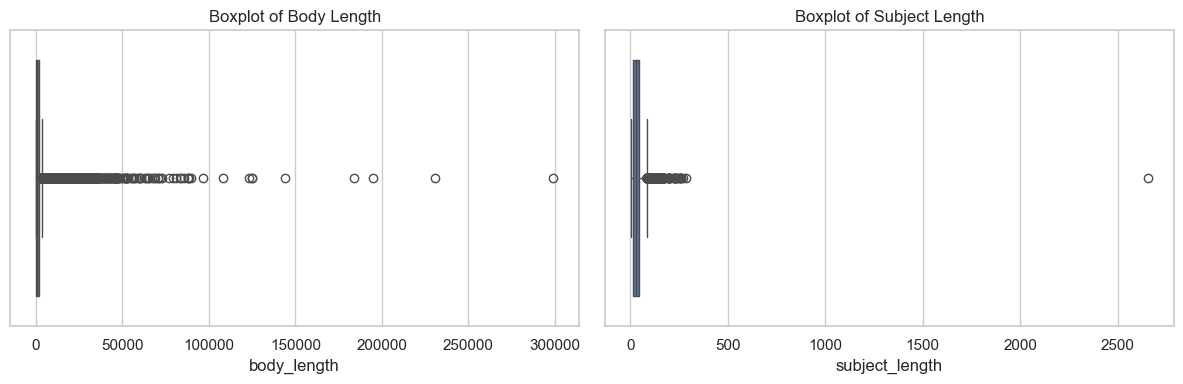

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_imputed['body_length'], ax=axes[0])
axes[0].set_title("Boxplot of Body Length")
sns.boxplot(x=df_imputed['subject_length'], ax=axes[1])
axes[1].set_title("Boxplot of Subject Length")
plt.tight_layout()
plt.show()

In [11]:
Q1  = df_imputed['body_length'].quantile(0.25)
Q3  = df_imputed['body_length'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1           = {Q1:.0f}")
print(f"Q3           = {Q3:.0f}")
print(f"IQR          = {IQR:.0f}")
print(f"Lower bound  = {lower:.0f}")
print(f"Upper bound  = {upper:.0f}")

outliers = df_imputed[(df_imputed['body_length'] < lower) | (df_imputed['body_length'] > upper)]
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(df_imputed)*100:.1f}%)")

Q1           = 149
Q3           = 1556
IQR          = 1407
Lower bound  = -1962
Upper bound  = 3666

Outliers detected: 6,800 (11.4%)


In [12]:
# Capping at 5th–95th percentile 
lower_cap = df_imputed['body_length'].quantile(0.05)
upper_cap = df_imputed['body_length'].quantile(0.95)

df_capped = df_imputed.copy()
df_capped['body_length'] = df_capped['body_length'].clip(lower_cap, upper_cap)

print(f"Capping strategy selected:")
print(f"  Lower cap (5th pct)  = {lower_cap:.0f}")
print(f"  Upper cap (95th pct) = {upper_cap:.0f}")
print(f"  Max before capping   = {df_imputed['body_length'].max():.0f}")
print(f"  Max after  capping   = {df_capped['body_length'].max():.0f}")
print(f"  Rows retained        : {len(df_capped):,} (no data loss)")

Capping strategy selected:
  Lower cap (5th pct)  = 35
  Upper cap (95th pct) = 4296
  Max before capping   = 299201
  Max after  capping   = 4296
  Rows retained        : 59,598 (no data loss)


### Decision: Capping (5th–95th percentile)

**Why NOT remove?** Long emails (newsletters, chains) are valid observations — removing them loses 11%+ of data.  
**Why Capping?** Retains all rows while limiting extreme influence on scaling and model training.



---
## Task 4: Data Transformation – Normalization

We apply both **Min-Max normalization** and **Z-Score standardization** to: `urls`, `body_length`, `subject_length`.

In [13]:
features = df_capped[['urls', 'body_length', 'subject_length']].copy()

# ── Force numeric conversion (handles unexpected string values) ──────────────
# Some datasets encode numbers as words (e.g. 'three' instead of 3).
# pd.to_numeric with errors='coerce' converts anything non-numeric to NaN,
# which we then fill with the column median so scaling can proceed.
for col in features.columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')
    n_coerced = features[col].isna().sum()
    if n_coerced > 0:
        median_val = features[col].median()
        features[col] = features[col].fillna(median_val)
        print(f"  '{col}': {n_coerced} non-numeric value(s) replaced with median ({median_val:.2f})")

print("\nFeature dtypes after coercion:")
print(features.dtypes)
print("\nAny nulls?", features.isna().sum().to_dict())
print("\nFeatures (first 5 rows):")
print(features.head())


  'urls': 32 non-numeric value(s) replaced with median (1.00)
  'body_length': 8 non-numeric value(s) replaced with median (470.00)

Feature dtypes after coercion:
urls              float64
body_length       float64
subject_length      int64
dtype: object

Any nulls? {'urls': 0, 'body_length': 0, 'subject_length': 0}

Features (first 5 rows):
   urls  body_length  subject_length
0   0.0       899.00              19
1   1.0       128.00              23
2   0.0       149.00              10
3   1.0       186.00              41
4   1.0      4295.75              43


### Min-Max Normalization

**Formula:** `x_norm = (x − x_min) / (x_max − x_min)`

Rescales all values to **[0, 1]**. Best for: **KNN, K-Means, SVM**.

In [14]:
scaler_mm = MinMaxScaler()
features_minmax = pd.DataFrame(
    scaler_mm.fit_transform(features),
    columns=features.columns
)

print("Min-Max normalized features (first 5 rows):")
print(features_minmax.head())
print(f"\nMin: {features_minmax.min().values}")
print(f"Max: {features_minmax.max().values}")

Min-Max normalized features (first 5 rows):
     urls  body_length  subject_length
0  0.0005     0.202781        0.006777
1  0.0006     0.021827        0.008283
2  0.0005     0.026756        0.003389
3  0.0006     0.035440        0.015060
4  0.0006     1.000000        0.015813

Min: [0. 0. 0.]
Max: [1. 1. 1.]


### Z-Score Standardization

**Formula:** `x_std = (x − mean) / std`

Transforms to **mean = 0, std = 1**. Best for: **Linear Regression, SVM, PCA**.

In [15]:
scaler_std = StandardScaler()
features_std = pd.DataFrame(
    scaler_std.fit_transform(features),
    columns=features.columns
)

print("Z-Score standardized features (first 5 rows):")
print(features_std.head())
print(f"\nMeans:    {features_std.mean().values.round(4)}")
print(f"Std devs: {features_std.std().values.round(4)}")

Z-Score standardized features (first 5 rows):
       urls  body_length  subject_length
0 -0.023829    -0.151934       -0.560211
1 -0.019129    -0.729884       -0.392455
2 -0.023829    -0.714142       -0.937661
3 -0.019129    -0.686407        0.362445
4 -0.019129     2.394304        0.446323

Means:    [-0. -0. -0.]
Std devs: [1. 1. 1.]


---
## Task 5: Data Reduction – PCA

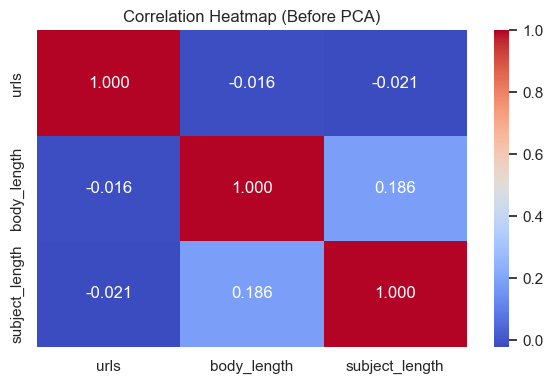

In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(features_std.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap (Before PCA)")
plt.tight_layout()
plt.show()

In [17]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(features_std.values)

print("Explained Variance Ratio:", pca.explained_variance_ratio_.round(4))
print("Cumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_).round(4))

Explained Variance Ratio: [0.3965 0.3322 0.2714]
Cumulative Explained Variance: [0.3965 0.7286 1.    ]


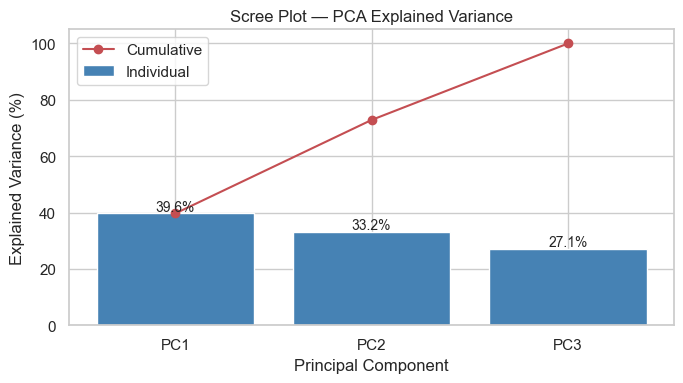

In [18]:
plt.figure(figsize=(7, 4))
components = ['PC1', 'PC2', 'PC3']
explained   = pca.explained_variance_ratio_ * 100
cumulative  = np.cumsum(pca.explained_variance_ratio_) * 100

plt.bar(components, explained, color='steelblue', label='Individual')
plt.plot(components, cumulative, 'r-o', label='Cumulative')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    plt.text(i, e + 1, f'{e:.1f}%', ha='center', fontsize=10)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot — PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

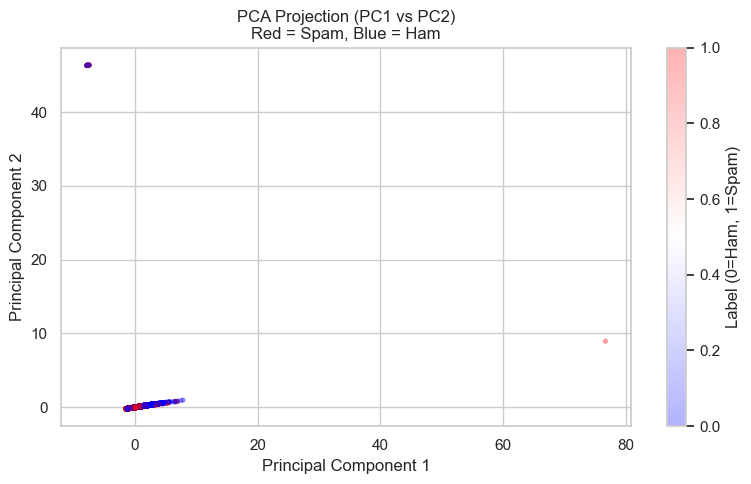

In [19]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    principal_components[:, 0], principal_components[:, 1],
    c=df_capped['label'], cmap='bwr', alpha=0.3, s=8
)
plt.colorbar(scatter, label='Label (0=Ham, 1=Spam)')
plt.title("PCA Projection (PC1 vs PC2)\nRed = Spam, Blue = Ham")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

---
## Assignment Summary

| Task | Action | Result |
|------|--------|--------|
| **Task 1** | Data quality assessment | Found missing values in 4 columns, wrong types, and label noise (label = 2) |
| **Task 2** | Noise removal + mode imputation | Dropped label = 2 rows; filled missing text fields with mode |
| **Task 3** | IQR outlier detection on `body_length` | Outliers capped at 5th–95th percentile; no rows lost |
| **Task 4** | Min-Max + Z-Score normalization | Applied to `urls`, `body_length`, `subject_length` |
| **Task 5** | PCA (3 components) | Variance spread across all 3 PCs; weak correlations limit compression benefit |

